In [62]:
import numpy as np
import matplotlib.pyplot as plt

In [89]:
Cor = 10
N = 200
dcor = Cor/(N-1)
T = 6
J = 800
dt = T/(J-1)

In [91]:
U = np.zeros((N,N))
print(U)

S = np.zeros((N,N))
k = int(0.5/dcor)
S[:, :k] = 0.1
print(S)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[[0.1 0.1 0.1 ... 0.  0.  0. ]
 [0.1 0.1 0.1 ... 0.  0.  0. ]
 [0.1 0.1 0.1 ... 0.  0.  0. ]
 ...
 [0.1 0.1 0.1 ... 0.  0.  0. ]
 [0.1 0.1 0.1 ... 0.  0.  0. ]
 [0.1 0.1 0.1 ... 0.  0.  0. ]]


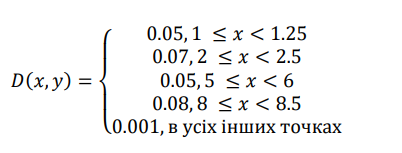

In [86]:
a1 = int(1/dcor)
a2 = int(1.25/dcor)
a3 = int(2/dcor)
a4 = int(2.5/dcor)
a5 = int(5/dcor)
a6 = int(6/dcor)
a7 = int(8/dcor)
a8 = int(8.5/dcor)

D = np.zeros((N,N))

d1 = 0.05
d2 = 0.07
d4 = 0.08
d0 = 0.001

for i in range(N):
    if a1 <= i < a2 or a5 <= i < a6:
        d=d1
    elif a3 <= i < a4:
        d=d2
    elif a7 <= i < a8:
        d=d4
    else: d = d0 
    if i > 0:
        D[i, i - 1] = d
    D[i, i] = -2 * d
    if i < N - 1:
        D[i, i + 1] = d
        
D[0,0] = -d0
D[N-1,N-1] = -d0

print(D)

[[-0.001  0.001  0.    ...  0.     0.     0.   ]
 [ 0.001 -0.002  0.001 ...  0.     0.     0.   ]
 [ 0.     0.001 -0.002 ...  0.     0.     0.   ]
 ...
 [ 0.     0.     0.    ... -0.002  0.001  0.   ]
 [ 0.     0.     0.    ...  0.001 -0.002  0.001]
 [ 0.     0.     0.    ...  0.     0.001 -0.001]]


In [92]:
print(U)
U_record = []
U_record.append(U.copy())
print(U_record)
Ycomp = np.zeros((N,N))
for k in range(J):
    for i in range(N):
        if a1 <= i < a2 or a5 <= i < a6:
            d=d1
        elif a3 <= i < a4:
            d=d2
        elif a7 <= i < a8:
            d=d4
        else: d = d0 
        for j in range(1, N-1):
            Ycomp[i,j] = d*(U[i,j+1] - 2*U[i,j] + U[i,j-1])
        Ycomp[i,0] = d*(U[i,1]-U[i,0])
    U += dt*((1/dcor**2)*(np.dot(D,U)+Ycomp)+S)
    U_record.append(U.copy())


[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(200, 200))]


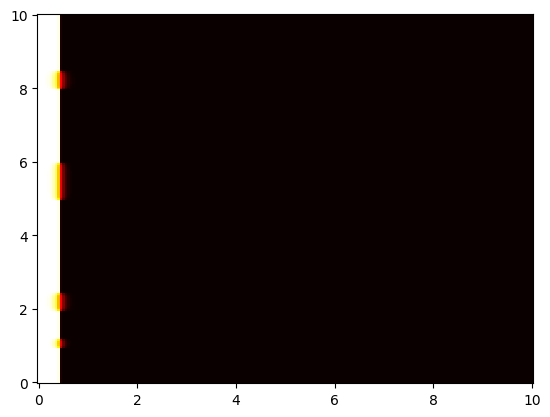

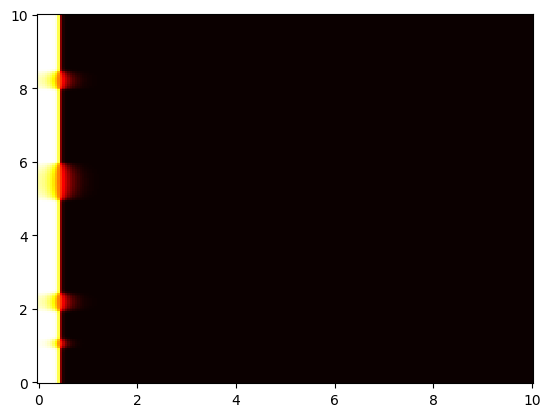

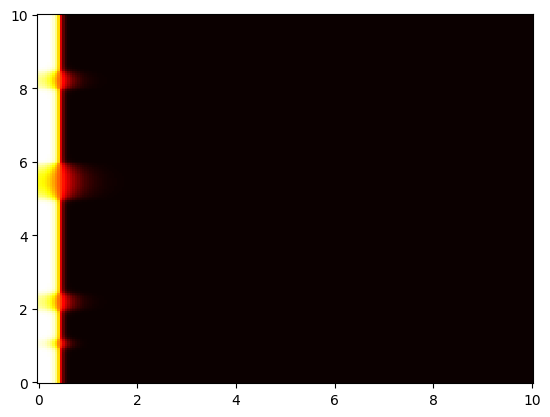

In [94]:
x_grid = np.array([j*dcor for j in range(N)])
Xc, Yc= np.meshgrid(x_grid, x_grid)
plt.pcolormesh(Xc, Yc, U_record[20], cmap='hot')
plt.show()
plt.pcolormesh(Xc, Yc, U_record[200], cmap='hot')
plt.show()
plt.pcolormesh(Xc, Yc, U_record[700], cmap='hot')
plt.show()